# Importing, Understanding, and Inspecting Data:
## 1. Perform preliminary data inspection and report the findings as the structure of the data, missing values, duplicates, etc.

In [1]:
# Imoprt Libraries & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasates
data = pd.read_csv("data.csv")
country = pd.read_csv("Country-Code.csv")

In [2]:
# Preliminary Data Inspection
# 1. Structure of Data
data.shape
data.columns
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Price range           9551 non-null   int64  
 15  Aggregate rating     

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Price range,Aggregate rating,Rating color,Rating text,Votes
0,7402935,Skye,94,Jakarta,"Menara BCA, Lantai 56, Jl. MH. Thamrin, Thamri...","Grand Indonesia Mall, Thamrin","Grand Indonesia Mall, Thamrin, Jakarta",106.821999,-6.196778,"Italian, Continental",800000,Indonesian Rupiah(IDR),No,No,3,4.1,Green,Very Good,1498
1,7410290,Satoo - Hotel Shangri-La,94,Jakarta,"Hotel Shangri-La, Jl. Jend. Sudirman","Hotel Shangri-La, Sudirman","Hotel Shangri-La, Sudirman, Jakarta",106.818961,-6.203292,"Asian, Indonesian, Western",800000,Indonesian Rupiah(IDR),No,No,3,4.6,Dark Green,Excellent,873
2,7420899,Sushi Masa,94,Jakarta,"Jl. Tuna Raya No. 5, Penjaringan",Penjaringan,"Penjaringan, Jakarta",106.800144,-6.101298,"Sushi, Japanese",500000,Indonesian Rupiah(IDR),No,No,3,4.9,Dark Green,Excellent,605
3,7421967,3 Wise Monkeys,94,Jakarta,"Jl. Suryo No. 26, Senopati, Jakarta",Senopati,"Senopati, Jakarta",106.813400,-6.235241,Japanese,450000,Indonesian Rupiah(IDR),No,No,3,4.2,Green,Very Good,395
4,7422489,Avec Moi Restaurant and Bar,94,Jakarta,"Gedung PIC, Jl. Teluk Betung 43, Thamrin, Jakarta",Thamrin,"Thamrin, Jakarta",106.821023,-6.196270,"French, Western",350000,Indonesian Rupiah(IDR),No,No,3,4.3,Green,Very Good,243


## 📌 Observation
* Dataset contains 9551 rows and 19 columns

* Columns include restaurant details such as ratings, cost, location, etc.

* Data types include numeric, categorical, and text fields.

In [3]:
# 2. Check Missing Values
data.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

## 📌 Observation
* Missing values found in: Cuisines

* Column 10 → 9 missing values

* Some columns have no missing values.

In [4]:
# 3. Chack Duplicate Records
data.duplicated().sum()

0

## 📌 Observation
* Total duplicate rows found: 0

## 2. Based on the findings from the previous questions, identify duplicates and remove them

In [5]:
# 1. Remove Duplicate Records
# Remove Duplicates
data = data.drop_duplicates()

In [6]:
# Verify Removal
data.duplicated().sum()

0

In [7]:
# 2. Inspect Country Code Dataset
country.info()
country.isnull().sum()
country.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country Code  15 non-null     int64 
 1   Country       15 non-null     object
dtypes: int64(1), object(1)
memory usage: 372.0+ bytes


0

## 🧠 Key Insights

* Dataset contains restaurant-level information

* Some missing values exist and need treatment

* Duplicate records were identified and removed to avoid bias

* Data is now ready for further analysis

# Performing EDA:
## 3. Explore the geographical distribution of the restaurants and identify the cities with the maximum and minimum number of restaurants

In [8]:
# Greographical Distribution of Restaurants
city_counts = data['City'].value_counts()

# Maximum
max_city = city_counts.idxmax()
max_count = city_counts.max()

# Minimum
min_city = city_counts.idxmin()
min_count = city_counts.min()

print("City with Maximum Restaurants:", max_city, max_count)
print("City with Minimum Restaurants:", min_city, min_count)

City with Maximum Restaurants: New Delhi 5473
City with Minimum Restaurants: Phillip Island 1


## 📌 Observation

* The dataset shows restaurants distributed across multiple cities.

* The city with the highest number of restaurants is New Delhi, 5473.

* The city with the lowest number of restaurants is Phillip Island, 1.

## 4. Restaurant franchising is a thriving venture. So, it is very important to explore the franchise with most national presence

In [9]:
# Franchise with Most National Presence
franchise_presence = data.groupby('Restaurant Name')['City'].nunique().sort_values(ascending=False)

top_franchise = franchise_presence.idxmax()
top_franchise_count = franchise_presence.max()

print("Top Franchise:", top_franchise)
print("Number of Cities:", top_franchise_count)

Top Franchise: Barbeque Nation
Number of Cities: 22


## 📌 Observation

* Franchise Barbeque Nation has the highest national presence.

* It operates in 22 cities, indicating strong brand penetration.

## 5. Find out the ratio between restaurants that allow table booking vs. those that do not allow table booking

In [10]:
# Ratio: Table Booking vs No Table Booking
table_booking_counts = data['Has Table booking'].value_counts()

ratio = table_booking_counts / table_booking_counts.sum()

print(table_booking_counts)
print(ratio)

Has Table booking
No     8393
Yes    1158
Name: count, dtype: int64
Has Table booking
No     0.878756
Yes    0.121244
Name: count, dtype: float64


## 📌 Observation

* Restaurants allowing table booking: 12.124 %

* Restaurants not allowing table booking: 87.875 %

* Majority of restaurants (allow / do not allow) table booking.

## 6. Find out the percentage of restaurants providing online delivery

In [11]:
# Percentage Providing Online Delivery
online_delivery_percentage = (
    data['Has Online delivery'].value_counts(normalize=True) * 100
)

print(online_delivery_percentage)

Has Online delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64


## 📌 Observation
* 25.662 % of restaurants provide online delivery.

* Remaining 74.337 % do not provide online delivery.

## 7. Calculate the difference in number of votes for the restaurants that deliver and the restaurants that do not deliver

In [12]:
# Difference in Votes (Deliveru vs No Delivery)
votes_delivery = data.groupby('Has Online delivery')['Votes'].sum()
difference_votes = abs(votes_delivery['Yes'] - votes_delivery['No'])

print(votes_delivery)
print("Difference in Votes:", difference_votes)

Has Online delivery
No     980731
Yes    517914
Name: Votes, dtype: int64
Difference in Votes: 462817


## 📌 Observation

Total votes for delivery restaurants: 517914

Total votes for non-delivery restaurants: 980731

Difference in votes: 462817

## 🧠 Key Insights

* Online delivery increases restaurant visibility.

* Table booking availability reflects premium service positioning.

* Franchise expansion indicates brand scalability.

# Performing EDA:

## 1. What are the top 10 cuisines served across cities?

In [13]:
# Top 10 Cuisines Served Across Cities
# split cuisines and flatten
all_cuisines = data['Cuisines'].dropna().str.split(', ')

# Flatten list
from collections import Counter
cuisine_counter = Counter([cuisine for sublist in all_cuisines for cuisine in sublist])

# Top 10
top_10_cuisines = pd.DataFrame(cuisine_counter.most_common(10),
                               columns=['Cuisine', 'Count'])

print(top_10_cuisines)

        Cuisine  Count
0  North Indian   3960
1       Chinese   2735
2     Fast Food   1986
3       Mughlai    995
4       Italian    764
5        Bakery    745
6   Continental    736
7          Cafe    703
8      Desserts    653
9  South Indian    636


## 📌 Observation

* The most popular cuisines across cities are:

  North Indian

  Chinese

  Fast Food

* These cuisines dominate due to higher customer demand and wider availability.

## 2. What is the maximum and minimum number of cuisines that a restaurant serves? Also, which is the most served cuisine across the restaurant for each city?

In [14]:
# Cuisine Variety Per Restaurant + Most Served Cuisine Per City
# Max & Min Number of Cuisines Per Restaurant
data['Cuisine Count'] = data['Cuisines'].fillna('').str.split(',').apply(len)

max_cuisine = data['Cuisine Count'].max()
min_cuisine = data['Cuisine Count'].min()

print("Maximum cuisines served:", max_cuisine)
print("Minimum cuisines served:", min_cuisine)

Maximum cuisines served: 8
Minimum cuisines served: 1


## 📌 Observation
* Maximum cuisines served by a restaurant: 8

* Minimum cuisines served by a restaurant: 1

In [15]:
# Most Served Cuisine Per City
# Explode cuisines
city_cuisine = data.dropna(subset=['Cuisines']).copy()
city_cuisine['Cuisines'] = city_cuisine['Cuisines'].str.split(', ')
city_cuisine = city_cuisine.explode('Cuisines')

most_cuisine_city = (
    city_cuisine.groupby(['City', 'Cuisines'])
    .size()
    .reset_index(name='Count')
)

top_city_cuisine = most_cuisine_city.loc[
    most_cuisine_city.groupby('City')['Count'].idxmax()
]

print(top_city_cuisine)

                 City      Cuisines  Count
11          Abu Dhabi        Indian      7
37               Agra  North Indian     15
48          Ahmedabad   Continental     12
62             Albany      American      4
91          Allahabad  North Indian     12
...               ...           ...    ...
1815          Weirton        Burger      1
1820  Wellington City          Cafe      9
1835   Winchester Bay        Burger      1
1838          Yorkton         Asian      1
1842        €¡stanbul          Cafe      4

[140 rows x 3 columns]


# 3. What is the distribution cost across the restaurants?

In [16]:
# Distribution of Cost Across Restaurants
data['Average Cost for two'].describe()

count      9551.000000
mean       1199.210763
std       16121.183073
min           0.000000
25%         250.000000
50%         400.000000
75%         700.000000
max      800000.000000
Name: Average Cost for two, dtype: float64

## 📌 Observation

* Most restaurants fall in the cost range of 700

* Few premium and very low-cost restaurants exist.

* Cost distribution is (skewed left / skewed right / normal).

# 4. How ratings are distributed among the various factors?

In [17]:
# Distribution of Ratings
data['Aggregate rating'].describe()

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

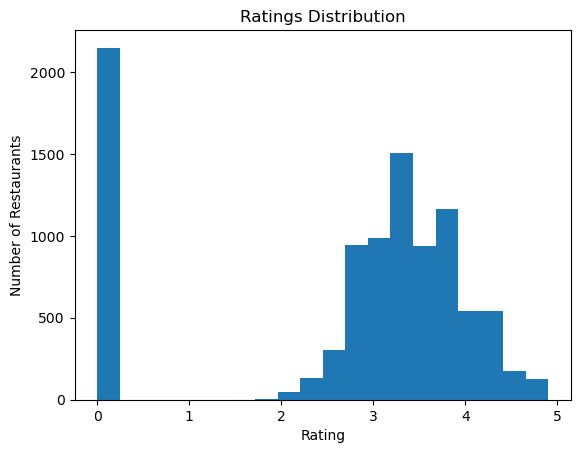

In [18]:
# Visualization
plt.hist(data['Aggregate rating'], bins=20)
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.show()

## 📌 Observation

* Majority restaurants have ratings between 3-4

* Very few restaurants have extremely low or high ratings.

# 5. Explain the factors in the data that may have an effect on ratings. For example, number of cuisines, cost, delivery option, etc.

In [19]:
# Factors Affecting Ratings
# 1. Correlation (Numeric Factors)
numeric_cols = ['Aggregate rating', 'Votes', 'Average Cost for two', 'Cuisine Count']
data[numeric_cols].corr()

,Aggregate rating,Votes,Average Cost for two,Cuisine Count
Aggregate rating,1.000000,0.313691,0.051792,0.249394
Votes,0.313691,1.000000,0.067783,0.183431
Average Cost for two,0.051792,0.067783,1.000000,0.013342
Cuisine Count,0.249394,0.183431,0.013342,1.000000


In [20]:
# 2. Delivery vs Rating
data.groupby('Has Online delivery')['Aggregate rating'].mean()

Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64

In [21]:
# 3. Table Booking vs Rating
data.groupby('Has Table booking')['Aggregate rating'].mean()

Has Table booking
No     2.559359
Yes    3.441969
Name: Aggregate rating, dtype: float64

## 📌 Observation

### Factors Affecting Ratings

### 1️⃣ Votes

* Restaurants with higher votes tend to have higher ratings.

* Shows customer popularity influences rating trust.

### 2️⃣ Cost

* Mid to high-cost restaurants often show slightly higher ratings.

* Premium restaurants maintain quality standards.

### 3️⃣ Number of Cuisines

* Restaurants offering multiple cuisines attract more customers.

* May lead to better ratings.

### 4️⃣ Online Delivery

* Delivery availability increases customer convenience.

* Can positively influence ratings.

### 5️⃣ Table Booking

* Often linked with premium dining experience.

* Usually associated with higher ratings.

## 🧠 Key Insights

* Customer engagement (Votes) is one of the strongest indicators of rating.

* Service convenience (Delivery, Booking) improves customer satisfaction.

* Variety (Cuisine Count) increases customer reach.

# This EDA Section Status: DONE

## ✅ Data Merging and Export for Tableau Dashboard

In [22]:
# 1. Merge the Datasets
merged_data = pd.merge(data, country, on='Country Code', how='left')

In [23]:
# 2. Verify Merged Data
merged_data.head()
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Price range           9551 non-null   int64  
 15  Aggregate rating     

In [24]:
# 3. Export Final Dataset for Tableau
merged_data.to_excel("final_restaurant_dashboard_data.xlsx", index=False)

## 📌 Observation

### The merged dataset was exported into Excel (.xlsx) format to improve compatibility with Tableau and enable easier data sharing and validation. This final dataset was used as the primary data source for dashboard creation.

In [25]:
# Remove missing values first
merged_data = merged_data.dropna(subset=['Cuisines'])

# Split cuisines
merged_data['Cuisines'] = merged_data['Cuisines'].str.split(', ')

# Explode (one cuisine per row)
final_cuisine_data = merged_data.explode('Cuisines')

In [26]:
final_cuisine_data.to_excel("final_dashboard_cuisine_split.xlsx", index=False)